# RAG with LlamaIndex - Loading and Storing


**RAG - Recap**

RAG is a technique where an application retrieves relevant information from a knowledge base and provides it to a Large Language Model (LLM) as context, so the model can generate accurate, grounded answers instead of relying solely on its memorised training data.

*A real-world analogy*: Imagine a customer support agent who has access to a company's entire product manual. When a customer asks a question, the agent does not memorise the manual - instead, the agent looks up the relevant pages, reads them, and then answers the customer in their own words. RAG works the same way: the retriever is the "lookup" step, and the LLM is the agent who reads and responds.

You have learnt about RAG in the previous sessions. Now let us implement it using LlamaIndex and OpenAI GPT models. This RAG pipeline will answer questions related to a specific set of documents and provide the location of its sources.


### LlamaIndex

**LlamaIndex** is a framework for building context-augmented LLM applications. Context augmentation refers to any use case that applies LLMs on top of your private or domain-specific data.


Some popular use cases include the following:
* Question-Answering Chatbots (commonly referred to as RAG, or "Retrieval-Augmented Generation")
* Document Understanding and Extraction
* Autonomous Agents that can perform research and take actions


LlamaIndex provides the tools to build any of these above use cases from prototype to production. The tools allow you to ingest and process this data and implement complex queries. It combines data access with LLM prompting.

[LlamaIndex API Reference](https://developers.llamaindex.ai/python/framework-api-reference/)

To install the library:

`pip install llama-index`

In [4]:
# %pip install -q llama-index

Note: you may need to restart the kernel to use updated packages.


LlamaIndex follows a modular packaging structure. The core library (`llama-index-core`) provides the foundational abstractions, while integrations - embedding models, LLMs, vector stores, data readers - are installed as separate packages.

In [ ]:
# You can also install the components separately like this
# %pip install -q llama-index-core llama-index-readers-file llama-index-embeddings-huggingface llama-index-embeddings-openai llama-index-llms-openai llama-index-llms-huggingface-api llama-index-vector-stores-chroma llama-index-vector-stores-faiss chromadb faiss-cpu

Note: you may need to restart the kernel to use updated packages.


### Core Components Of LlamaIndex

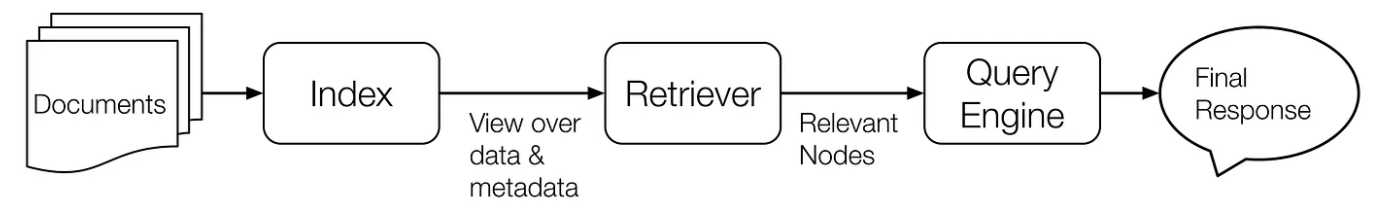

You can understand the core components of Llamaindex with this analogy:
1. Documents: These are the "books" in your library.
2. Index: It's the "library" of your data - Stores your data.
3. Retriever: It's the "librarian" that finds relevant data - Finds data.
4. Response Synthesizer: It's the "storyteller" that creates a response - Makes responses.
5. QueryEngine: It's the "director" that makes everything work together - Coordinates everything.

---

## [Data Loading (Ingestion)](https://developers.llamaindex.ai/python/framework/understanding/rag/loading/)

### Documents

Before your LLM can act on your data, you need to process and load it. The way LlamaIndex does this is via data connectors, also called `Reader`. 

Data connectors ingest data from different data sources and format the data into `Document` objects. 

A `Document` in LlamaIndex is the framework's representation of a single source of data - a file, a database record, or an API response. It holds the raw text content along with metadata (such as the filename, creation date, or any custom attributes).

***Ingestion Methods***

- If you have a single file containing all the required data, use a data loader or reader from [LLamahub](https://llamahub.ai/?tab=readers) 
- If you have multiple files, the simplest way is to use [*SimpleDirectoryReader*](https://developers.llamaindex.ai/python/framework/module_guides/loading/simpledirectoryreader/). <br>
    It is built in to LlamaIndex and can read a variety of formats including Markdown, PDFs, Word documents, PowerPoint decks, images, audio and video. Just ensure that for reading each file type the necessary dependency libraries are already installed.
- Llamaparse: A very recent method for parsing documents, mainly for agentic workflows. This is claimed as the first GenAI native document parsing platform.

#### SimpleDirectoryReader

Let's load the data to be used now. We will use `SimpleDirectoryReader`. Here are some attributes that can be passed to it:

* `input_dir`: The directory from which you have to load files.
* `recursive`: If set to *True*, it will read files from subdirectories too.
* `input_files`: A list of specific file paths to load.
* `exclude`: A list of file paths to exclud

In [7]:
from llama_index.core import SimpleDirectoryReader

# Let us take input from a directory
reader = SimpleDirectoryReader(input_dir="./data")

In [ ]:
# Use the load_data() method to read the files from the directory
documents = reader.load_data()
# number of files
print(f"Loaded {len(documents)} docs")

In [18]:
# gives a list of documents; check the structure
documents[:5]

[Document(id_='16245aae-7ee1-41b5-bac6-ae6a0ccd247c', embedding=None, metadata={'page_label': '1', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='UNITED STATES\nSECURITIES AND EXCHANGE COMMISSION\nWashington, D.C. 20549\n____________________________________________ \nFORM 10-K\n____________________________________________ \n(Mark One)\n☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the fiscal year ended December 31, 2022\nOR\n☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the transition period from_____ to _____            \nCommission File Number: 001-38902 \n____________________________________________ \nUBER TECHNOLOGIES, INC. \n(Exact name of registrant as specified in its charter)\n_____________________

Note that we are only loading one document, but the reader has loaded multiple documents. This is because the reader is considering each page as one document. This is better because more information about less text can be stored in the metadata. See an example where we read the first document from the list.

Each Document object exposes several useful attributes that can be inspected. The cell below shows the structure of a single Document.

In [ ]:
sample_doc = documents[0]

print(f"Document ID   : {sample_doc.doc_id}")
print(f"Text length   : {len(sample_doc.text)} characters")
print(f"Metadata      : {sample_doc.metadata}")
print(f"\nText preview:\n{sample_doc.text[:200]}...")

A feature provided for metadata extraction is using LLM to do so. Refer to [`metadata_extractor`](https://developers.llamaindex.ai/python/framework/module_guides/loading/documents_and_nodes/usage_metadata_extractor/) for understanding the usage.

#### Document Readers

We can also use other file based readers apart from directly using the directory reader

In [17]:
# Instead of SimpleDirectoryReader, we are using another loader for PDFs called PDFReader
from llama_index.readers.file import PDFReader


loader = PDFReader()
documents = loader.load_data(file = 'data/uber_2022.pdf')
print(f"Loaded {len(documents)} docs")

Loaded 149 docs


You can also construct documents manually, in case you do not want to read from a source. Refer to [this documentation](https://developers.llamaindex.ai/python/framework/module_guides/loading/documents_and_nodes/usage_documents/).

---

### Parsing Documents into Nodes

A **Node** is LlamaIndex's term for a chunk - a smaller, semantically focused piece of a Document. Nodes are the fundamental units that get embedded and stored in the index. When a query is made, the system retrieves Nodes, not entire Documents.


Nodes are a first-class citizen in LlamaIndex. You can choose to define Nodes and all its attributes directly. You may also choose to "parse" source Documents into Nodes through our `NodeParser` classes. 

By default every Node derived from a Document will inherit the same metadata from that Document (e.g. a "file_name" filed in the Document is propagated to every Node).



Both Documents and Nodes have unique identifies called `ID`. These can be set automatically or manually. `ID` is generally used to identify, update, and define relationships between documents (or nodes).

For additional reading: [Documents / Nodes](https://docs.llamaindex.ai/en/stable/module_guides/loading/documents_and_nodes/#documents-nodes)


Think of it this way, if a Document is a book, a Node is a highlighted passage within that book. When a researcher is looking for information about a specific topic, they do not read entire books cover-to-cover - they look up relevant passages. Nodes serve the same purpose: they are the passages that the retriever searches through.

Nodes are more than just text fragments. Each Node carries:
- The **chunk text** itself
- **Metadata** inherited from its parent Document (and any additional metadata)
- **Relationships** - links to its parent Document, and to the previous and next Nodes in sequence

#### Node Parsers

The process of splitting Documents into Nodes is handled by a **NodeParser** (also called a text splitter). LlamaIndex provides several built-in parsers. The most commonly used is `SentenceSplitter`, which splits text on sentence boundaries while respecting a configurable chunk size and overlap.

**Why chunk size and overlap matter**:
- **Chunk size** controls how much text each Node contains. Smaller chunks (128-256 tokens) produce more precise retrieval but may lose surrounding context. Larger chunks (512-1024 tokens) retain more context but may dilute the embedding signal.
- **Overlap** ensures that information at chunk boundaries is not lost. If a key sentence spans the boundary between two chunks, the overlap ensures it appears in both.

Reference: [`node_parsers`](https://developers.llamaindex.ai/python/framework/module_guides/loading/node_parsers/)

> Chunk size directly affects the number of nodes - and therefore the number of embeddings to compute. A document with 100K tokens produces ~435 nodes at `chunk_size=256` but only ~108 nodes at `chunk_size=1024`. For large corpora (100+ pages), use `chunk_size=512` or `1024` to keep indexing time and embedding costs manageable.

In [19]:
from llama_index.core.node_parser import SentenceSplitter

total_chars = sum(len(doc.text) for doc in documents)
print(f"Total documents     : {len(documents)}")
print(f"Total characters    : {total_chars:,}")
print(f"Estimated tokens    : ~{total_chars // 4:,}")
print()

parser = SentenceSplitter(
    chunk_size=512,
    chunk_overlap=50
)

nodes = parser.get_nodes_from_documents(documents)

print(f"Chunk size          : 512 tokens")
print(f"Overlap             : 50 tokens")
print(f"Total nodes created : {len(nodes)}")
# Each node will require one embedding call during indexing

Total documents     : 149
Total characters    : 689,448
Estimated tokens    : ~172,362

Chunk size          : 512 tokens
Overlap             : 50 tokens
Total nodes created : 388


An interesting point to note, you can also use [LangChain text splitter](https://developers.llamaindex.ai/python/framework/module_guides/loading/node_parsers/modules/#langchainnodeparser) classes with `NodeParser`

In [25]:
nodes[0]

TextNode(id_='82dd31da-ffd0-4d72-9393-2fa370c296b6', embedding=None, metadata={'page_label': '1', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='16245aae-7ee1-41b5-bac6-ae6a0ccd247c', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'page_label': '1', 'file_name': 'uber_2022.pdf'}, hash='0f1fab1c7bf7b754112b733359fbadac1c4eecd9bc50f79166b6c0d86efdc841'), <NodeRelationship.NEXT: '3'>: RelatedNodeInfo(node_id='ddf6ccde-f8cb-47e5-a271-eb55ccfba23a', node_type=<ObjectType.TEXT: '1'>, metadata={}, hash='cdfa3e648dc168003d0ebd8acca3e3c2762c40cc7f52b401c18eff2c821c7ac8')}, metadata_template='{key}: {value}', metadata_separator='\n', text='UNITED STATES\nSECURITIES AND EXCHANGE COMMISSION\nWashington, D.C. 20549\n____________________________________________ \nFORM 10-K\n____________________________________________ \n(Mark One)\n☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) O

In [ ]:
from llama_index.core.schema import TextNode

# A node object looks like this
TextNode(
    id_='82dd31da-ffd0-4d72-9393-2fa370c296b6', 
    embedding=None,
    metadata={
        'page_label': '1', 'file_name': 'uber_2022.pdf'
        }, 
    excluded_embed_metadata_keys=[], 
    excluded_llm_metadata_keys=[], 
    relationships={
        <NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='16245aae-7ee1-41b5-bac6-ae6a0ccd247c', 
                                                        node_type=<ObjectType.DOCUMENT: '4'>, 
                                                        metadata={'page_label': '1', 'file_name': 'uber_2022.pdf'}, 
                                                        hash=''
                                                    ),
        <NodeRelationship.NEXT: '3'>: RelatedNodeInfo(node_id='ddf6ccde-f8cb-47e5-a271-eb55ccfba23a', 
                                                      node_type=<ObjectType.TEXT: '1'>, 
                                                      metadata={}, 
                                                      hash=''
                                                    )
                }, 
    metadata_template='{key}: {value}', 
    metadata_separator='\n', 
    text='....', 
    mimetype='text/plain', 
    start_char_idx=0, 
    end_char_idx=1925, 
    text_template='{metadata_str}\n\n{content}'
    )

#### Inspecting Nodes and Their Relationships

Unlike simple text chunks in other frameworks, LlamaIndex Nodes are aware of their context. Each Node knows which Document it came from (its parent) and which Nodes come before and after it (its siblings). This relationship information enables advanced retrieval patterns, such as fetching surrounding context after finding a relevant chunk.

[Defining and Customising Nodes](https://developers.llamaindex.ai/python/framework/module_guides/loading/documents_and_nodes/usage_nodes/)

In [20]:
from llama_index.core.schema import NodeRelationship

for i, node in enumerate(nodes[:4]):
    print(f"{'='*65}")
    print(f"Node {i}")
    print(f"{'='*65}")
    print(f"  ID       : {node.node_id[:40]}...")
    print(f"  Text     : \"{node.text[:100].replace(chr(10), ' ')}...\"")
    print(f"  Chars    : {len(node.text)}")
    print(f"  Metadata : {node.metadata}")

    rels = node.relationships
    if NodeRelationship.SOURCE in rels:
        print(f"  Parent   : {rels[NodeRelationship.SOURCE].node_id[:40]}...")
    if NodeRelationship.PREVIOUS in rels:
        print(f"  Previous : {rels[NodeRelationship.PREVIOUS].node_id[:40]}...")
    if NodeRelationship.NEXT in rels:
        print(f"  Next     : {rels[NodeRelationship.NEXT].node_id[:40]}...")
    print()

Node 0
  ID       : 82dd31da-ffd0-4d72-9393-2fa370c296b6...
  Text     : "UNITED STATES SECURITIES AND EXCHANGE COMMISSION Washington, D.C. 20549 ____________________________..."
  Chars    : 1925
  Metadata : {'page_label': '1', 'file_name': 'uber_2022.pdf'}
  Parent   : 16245aae-7ee1-41b5-bac6-ae6a0ccd247c...
  Next     : ddf6ccde-f8cb-47e5-a271-eb55ccfba23a...

Node 1
  ID       : ddf6ccde-f8cb-47e5-a271-eb55ccfba23a...
  Text     : "Yes  ☒	 No  ☐ Indicate by check mark whether the registrant has submitted electronically every Inter..."
  Chars    : 687
  Metadata : {'page_label': '1', 'file_name': 'uber_2022.pdf'}
  Parent   : 16245aae-7ee1-41b5-bac6-ae6a0ccd247c...
  Previous : 82dd31da-ffd0-4d72-9393-2fa370c296b6...

Node 2
  ID       : 87a163b7-8d6e-41f3-92ae-d9c21e4a614d...
  Text     : "Large accelerated filer ☒ Accelerated filer ☐ Non-accelerated filer ☐ Smaller reporting company ☐ Em..."
  Chars    : 2214
  Metadata : {'page_label': '2', 'file_name': 'uber_2022.pdf'}
  Paren

#### Adding Metadata to Nodes

**Metadata** is structured information attached to each Node - key-value pairs that describe attributes of the content, such as the document's source, department, date, category, or any other useful label.

Metadata serves two purposes in a RAG system:
1. **Filtering**: At query time, metadata filters can restrict retrieval to only Nodes that match certain criteria (e.g., "only return nodes from the finance department" or "only documents from 2024").
2. **Context**: Metadata is included in the LLM prompt, giving the model additional structured information about the source of each passage.

LlamaIndex allows metadata to be attached at the Document level (it flows down to all Nodes of the Document) or at the Node level (for finer control).

In [52]:
documents[0]

Document(id_='16245aae-7ee1-41b5-bac6-ae6a0ccd247c', embedding=None, metadata={'page_label': '1', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='UNITED STATES\nSECURITIES AND EXCHANGE COMMISSION\nWashington, D.C. 20549\n____________________________________________ \nFORM 10-K\n____________________________________________ \n(Mark One)\n☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the fiscal year ended December 31, 2022\nOR\n☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the transition period from_____ to _____            \nCommission File Number: 001-38902 \n____________________________________________ \nUBER TECHNOLOGIES, INC. \n(Exact name of registrant as specified in its charter)\n______________________

In [63]:
# Let's say you want to add a metadata field to doc with page label 3, 4
metadata_map = {
    "3": {"department": "corporate"},
    "4": {"department": "finance"},
                }

edited_docs = []

# we will add this on a document level, 
# as each doc is split into multiple nodes (updating once for multiple nodes)
for doc in documents:
    docpage = doc.metadata.get("page_label")
    data_to_add = metadata_map.get(docpage, {}) # 
    doc.metadata.update(data_to_add)
    edited_docs.append(doc)

# Then, move forward with the pipeline using edited_docs

In [ ]:
# See the edited metadata
edited_docs[2]

Document(id_='db635d87-fa95-4988-b62c-b2b4888db36b', embedding=None, metadata={'page_label': '3', 'file_name': 'uber_2022.pdf', 'department': 'corporate'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='UBER TECHNOLOGIES, INC.\nTABLE OF CONTENTS\nPages\nSpecial Note Regarding Forward-Looking Statements 2\nPART I\nItem 1. Business 4\nItem 1A. Risk Factors 10\nItem 1B. Unresolved Staff Comments 45\nItem 2. Properties 45\nItem 3. Legal Proceedings 45\nItem 4. Mine Safety Disclosures 46\nPART II\nItem 5. Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities 46\nItem 6. [Reserved] 47\nItem 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations 47\nItem 7A. Quantitative and Qualitative Disclosures About Market Risk 67\nItem 8. Financial Statements a

---

## Index and Vector Stores

An `Index` is a data structure that allows us to quickly retrieve relevant context for a user query. For LlamaIndex, it's the core foundation for RAG use-cases.

At a high-level, Indexes are built from Documents. They are used to build Query Engines and Chat Engines which enables question & answer and chat over your data.

Under the hood, Indexes store data in Node objects, and expose a Retriever interface that supports additional configuration and automation.

The most common index by far is the `VectorStoreIndex` (index of vectors or embeddings). Others are Summary Index (or List Index), Tree Index, Keyword Table Index, and Property Graph Index.

To know more about how these indexes work, refer to [this explanation](https://developers.llamaindex.ai/python/framework/module_guides/indexing/index_guide/)

### Vector Store Index

A **VectorStoreIndex** is LlamaIndex's primary data structure for semantic search. It takes the Nodes, converts each one into a numerical vector (an embedding) using an embedding model, and stores those vectors in a searchable index.

For example, if Nodes are highlighted passages in a library's books, the `VectorStoreIndex` is the library's search catalogue. When someone asks a question, the catalogue identifies which passages are most relevant - not by matching keywords, but by understanding the meaning of the question.

When `VectorStoreIndex.from_documents()` is called, LlamaIndex performs three steps automatically:
1. Splits and **parses** Documents into Node objects (using the configured NodeParser)
2. **Embeds** each Node using the configured embedding model
3. **Stores** the embeddings in the vector store (in-memory by default)

[Using `VectorStoreIndex` -  Reference](https://developers.llamaindex.ai/python/framework/module_guides/indexing/vector_store_index/) and [Using Vector Stores Reference](https://developers.llamaindex.ai/python/framework/community/integrations/vector_stores/)

By default, `VectorStoreIndex` uses an in-memory `SimpleVectorStore` that is initialised as part of the default storage context.

In [21]:
from llama_index.core import VectorStoreIndex

# uses OpenAI embedding model by default (refer to next section)
demo_index = VectorStoreIndex.from_documents(documents)

2026-03-26 19:28:51,983 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-26 19:28:53,619 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-26 19:28:56,685 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


To add more nodes to the index:

In [ ]:
# demo_index.insert(doc123)

Most indexes allow for the usual CRUD operations. You can refer to [this guide on document management](https://developers.llamaindex.ai/python/framework/module_guides/indexing/document_management/)

### Embeddings

LlamaIndex provides embedding models as well

[Embeddings reference](https://developers.llamaindex.ai/python/framework/module_guides/models/embeddings/#list-of-supported-embeddings)

In [ ]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

embed_model = HuggingFaceEmbedding(model_name="all-MiniLM-L6-v2")   # token should be in .env

In [23]:
embeddings = embed_model.get_text_embedding("Hello World!")
print(len(embeddings))
print(embeddings[:5])

384
[-0.020386911928653717, 0.02528083324432373, -0.0005662564071826637, 0.01161540299654007, -0.03798839822411537]


We can also define the defaults (such as default LLMs or embedding model) that LlamaIndex components use with the [Settings module](https://developers.llamaindex.ai/python/framework/module_guides/supporting_modules/settings/)

In [ ]:
from llama_index.core import Settings
from llama_index.llms.openai import OpenAI
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI

Settings.embed_model = embed_model
# Settings.llm = OpenAI(model="gpt-4o-mini", temperature=0.1)
Settings.llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen2.5-7B-Instruct")

Settings.chunk_size = 512
Settings.chunk_overlap = 50

# see the new defaults
Settings.llm, Settings.embed_model, Settings.chunk_size

(HuggingFaceInferenceAPI(callback_manager=<llama_index.core.callbacks.base.CallbackManager object at 0x0000017E619B7ED0>, rate_limiter=None, system_prompt=None, messages_to_prompt=<function messages_to_prompt at 0x0000017E3F073E20>, completion_to_prompt=<function default_completion_to_prompt at 0x0000017E3F3DFF60>, output_parser=None, pydantic_program_mode=<PydanticProgramMode.DEFAULT: 'default'>, query_wrapper_prompt=None, model=None, model_name='HuggingFaceH4/zephyr-7b-beta', provider='auto', token=None, timeout=None, headers=None, cookies=None, task='conversational', context_window=3900, num_output=256, temperature=0.1, is_chat_model=True, is_function_calling_model=False),
 HuggingFaceEmbedding(model_name='all-MiniLM-L6-v2', embed_batch_size=10, callback_manager=<llama_index.core.callbacks.base.CallbackManager object at 0x0000017E619B7ED0>, num_workers=None, embeddings_cache=None, rate_limiter=None, max_length=256, normalize=True, query_instruction=None, text_instruction=None, cache

Now, we can build the vector index using the custom embedding model

In [31]:
demo_index = VectorStoreIndex.from_documents(documents, show_progress=True)

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/388 [00:00<?, ?it/s]

##### Pre-Calculated Embeddings

Usually, with the `VectorStoreIndex.from_documents()` method, you do not get the option to add pre-calculated embeddings. If you wish to not calculate embeddings while index building, you can add them to the nodes themselves. 

We use the `embedding` attribute of the `TextNode` object

In [ ]:
# This is how a node object looks
TextNode(
    id_='82dd31da-ffd0-4d72-9393-2fa370c296b6',

    embedding=None,     # Add the node's embedding here
    
    metadata={
        'page_label': '1', 'file_name': 'uber_2022.pdf'
        }, 
    excluded_embed_metadata_keys=[], 
    excluded_llm_metadata_keys=[], 
    relationships={}, 
    metadata_template='{key}: {value}', 
    metadata_separator='\n', 
    text='....', 
    mimetype='text/plain', 
    start_char_idx=0, 
    end_char_idx=1925, 
    text_template='{metadata_str}\n\n{content}')

If the node objects have embeddings present, the vector store does not need to recalculate them during the build

In [33]:
node = nodes[0]

node.embedding = embed_model.get_text_embedding(node.text)

node

TextNode(id_='82dd31da-ffd0-4d72-9393-2fa370c296b6', embedding=[-0.05959824472665787, -0.006807129830121994, -0.04833200201392174, -0.04996328428387642, -0.05721595138311386, 0.05837635323405266, 0.01460209395736456, 0.0633283257484436, -0.07672227174043655, 0.02438013069331646, 0.06457947194576263, 0.026806732639670372, 0.0021811299957334995, -0.02078678086400032, -0.016748566180467606, 0.08992087841033936, 0.005933345761150122, -0.007286549545824528, -0.00881837960332632, 0.031915053725242615, 0.045704878866672516, -0.02869785949587822, -0.04638877883553505, -0.049235861748456955, 0.04051936790347099, -0.024602742865681648, -0.04546008259057999, 0.007403144147247076, -0.07327687740325928, -0.009689169004559517, -0.019450608640909195, 0.012393188662827015, -0.0015302059473469853, 0.0206304881721735, 0.11735618859529495, -0.05978408083319664, 0.03421572595834732, -0.017901355400681496, 0.08007203042507172, -0.08283096551895142, 0.03360060602426529, -0.054328951984643936, -0.01704809628


**Important note**: The embedding model used at index time must be the same model used at query time. E.g., If documents are embedded with `text-embedding-3-small`, queries must also be embedded with `text-embedding-3-small`. Mixing embedding models produces vectors in incompatible vector spaces, and similarity scores will be meaningless.

---
### Persisting the Index to Disk

By default, a `VectorStoreIndex` lives entirely in memory. This means that if the Python process ends - whether by restarting the notebook kernel or shutting down the application - all the indexed data is lost, and the documents would need to be re-embedded from scratch.

**Persistence** solves this problem by writing the index (embeddings, node content, metadata, and the index structure) to disk. The next time the application starts, it can reload the index from disk in a fraction of the time it would take to re-embed everything.

For example, persistence is like saving a library's catalogue to a file. Without it, the librarian would need to re-catalogue every book each morning. With it, the catalogue is ready the moment the library opens.

LlamaIndex provides a built-in [`StorageContext`](https://developers.llamaindex.ai/python/framework/understanding/rag/storing/#persisting-to-disk) that handles serialisation to a local directory.

In [35]:
PERSIST_DIR = "./index_storage"

demo_index.storage_context.persist(persist_dir=PERSIST_DIR)

print(f"Index persisted to: {PERSIST_DIR}")


import os

print("\nFiles created:")
for f in os.listdir(PERSIST_DIR):
    size_kb = os.path.getsize(os.path.join(PERSIST_DIR, f)) / 1024
    print(f"  {f} ({size_kb:.1f} KB)")

Index persisted to: ./index_storage

Files created:
  default__vector_store.json (3346.7 KB)
  docstore.json (1232.6 KB)
  graph_store.json (0.0 KB)
  image__vector_store.json (0.1 KB)
  index_store.json (32.1 KB)


#### Reloading the Index from Disk

You can reaload a persisted index. In a production application, this is how the system would start up - loading a pre-built index rather than re-embedding the entire corpus on every restart.

In [37]:
from llama_index.core import StorageContext, load_index_from_storage

storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
reloaded_index = load_index_from_storage(storage_context)

print("Index reloaded from disk successfully.")

2026-03-26 21:26:52,135 - INFO - Loading all indices.


Index reloaded from disk successfully.


This reloaded index can be queried exactly like the original

---
### Switching Vector Store

By default, LlamaIndex stores embeddings in a simple **in-memory** vector store. This is convenient for prototyping but has two limitations: (1) data is lost when the process ends, and (2) it does not scale to large corpora.

A [**vector store**](https://developers.llamaindex.ai/python/framework/module_guides/storing/vector_stores/) (or vector database) is a specialised database designed to store, index, and search high-dimensional vectors efficiently. LlamaIndex supports 30+ vector store integrations, allowing the same code to work with different backends by swapping a single component.

The in-memory store is like writing the library catalogue on a whiteboard - fast to create, but erased when someone cleans the board. ChromaDB is like storing the catalogue in a filing cabinet - the data persists, and the cabinet can hold far more entries.


[Using other vector stores - guide](https://developers.llamaindex.ai/python/framework/understanding/rag/storing/#using-vector-stores)

#### ChromaDB

ChromaDB supports persistent storage, metadata filtering, and automatic embedding. LlamaIndex integrates with ChromaDB as the `ChromaVectorStore` through the `llama-index-vector-stores-chroma` package.



First, we normally create a Chroma collection

In [ ]:
import chromadb
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core import StorageContext

# chroma_persistent_client = chromadb.PersistentClient(path="./chroma_llamaindex_db") 
# or
chroma_client = chromadb.Client()

chroma_collection = chroma_client.get_or_create_collection("chroma_vectorstore")

Then we must define this created collection as a `ChromaVectorStore` object

In [ ]:
chroma_vector_store = ChromaVectorStore(chroma_collection=chroma_collection)

Now, because we are building an index from a custom vector store, we must again provide a storage context which declares what vector store object we are using.

In [43]:
chroma_storage_context = StorageContext.from_defaults(vector_store=chroma_vector_store)

Finally, we add this context and build the `VectorStoreIndex`

In [44]:
chroma_index = VectorStoreIndex.from_documents(
    documents,
    storage_context=chroma_storage_context,
    show_progress=True
)

print(f"ChromaDB index created.")
print(f"  Collection     : {chroma_collection.name}")
print(f"  Documents      : {chroma_collection.count()}")
# print(f"  Persist path   : ./chroma_llamaindex_db/")

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/388 [00:00<?, ?it/s]

ChromaDB index created.
  Collection     : chroma_vectorstore
  Documents      : 776


##### Reloading a ChromaDB Index

If you use a persistent collection, the index can be reloaded without re-embedding

In [ ]:
# reloaded_chroma_client = chromadb.PersistentClient(path="./chroma_llamaindex_db")

reloaded_collection = reloaded_chroma_client.get_collection("chroma_vectorstore")

reloaded_vector_store = ChromaVectorStore(chroma_collection=reloaded_collection)
reloaded_index = VectorStoreIndex.from_vector_store(
    reloaded_vector_store,
    embed_model=Settings.embed_model
)

---
### FAISS

**FAISS** (Facebook AI Similarity Search) is a library developed by Meta Research for extremely fast similarity search over dense vectors. 

Now, we already know that unlike ChromaDB, FAISS is not a database - it is a low-level indexing library that provides raw speed at the cost of higher-level features (no built-in embedding, metadata filtering, no automatic persistence).

If ChromaDB is a well-organised filing cabinet with labelled folders, FAISS is a high-speed sorting machine. It finds matching items incredibly fast but does not label or organise them - that responsibility falls on the application.

FAISS is the right choice when raw retrieval speed is the priority, particularly for very large corpora (millions of vectors) or when GPU acceleration is available.

FAISS does not produce embeddings while indexing. LlamaIndex handles that for us.

We can normally create a FAISS index as usual with just the embedding dimensions

In [46]:
import faiss
from llama_index.vector_stores.faiss import FaissVectorStore

embed_dim = 384  # miniLM embeddings are 384-dimensional vectors
faiss_index = faiss.IndexFlatL2(embed_dim)

2026-03-26 22:27:06,442 - INFO - Loading faiss with AVX2 support.
2026-03-26 22:27:06,832 - INFO - Successfully loaded faiss with AVX2 support.


Now similar steps as for Chroma, we create a vector store, add it to context, and build the `VectorStoreIndex`. 

In [47]:
faiss_vector_store = FaissVectorStore(faiss_index=faiss_index)
faiss_storage_context = StorageContext.from_defaults(vector_store=faiss_vector_store)

In [48]:
faiss_li_index = VectorStoreIndex.from_documents(
    documents,
    storage_context=faiss_storage_context,
    show_progress=True
)

print(f"FAISS index created.")
print(f"  Dimension    : {embed_dim}")
print(f"  Index type   : IndexFlatL2 (exact search)")
print(f"  Vectors      : {faiss_index.ntotal}")

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/388 [00:00<?, ?it/s]

FAISS index created.
  Dimension    : 384
  Index type   : IndexFlatL2 (exact search)
  Vectors      : 388


From these demonstrations, you might have now realised the different between a vector store and a vector store index. Vector store is just a tool that enables storage and search over the embeddings. 

Index defines how data is processed and retrieved within the RAG pipeline. The vector store index is a higher-level abstraction that manages the full retrieval pipeline.

### Vector Store Comparison

The table below summarises the trade-offs between the three vector store options demonstrated in this tutorial:

| Feature | In-Memory (Default) | ChromaDB | FAISS |
|---|---|---|---|
| **Persistence** | None (lost on restart) | Built-in (file-based) | Manual (save/load) |
| **Metadata filtering** | Basic | Rich (key-value filters) | None built-in |
| **Speed** | Fast (small corpora) | Fast | Very fast (optimised C++) |
| **Scalability** | Small only | Small to medium | Large (millions of vectors) |
| **Setup complexity** | Zero | Low (pip install) | Low (pip install) |
| **Best for** | Prototyping, tutorials | Production with filtering | Speed-critical, large-scale |

To perform search on an index, we just create a retriever from it, just like LangChain.

In [49]:
retriever = chroma_index.as_retriever(similarity_top_k=5)

query = 'What information do you have about the mobility service of uber?'
retriever.retrieve(query)

[NodeWithScore(node=TextNode(id_='bb91f351-e8e7-49a1-bfd1-9288b137aff7', embedding=None, metadata={'page_label': '12', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='cb266651-4a1c-45e3-97c8-aca8a2a8ca69', node_type='4', metadata={'page_label': '12', 'file_name': 'uber_2022.pdf'}, hash='0b0327c9fcc8f0e578de28533d2964d1f936e1d6a82566c211396bab7c899735'), <NodeRelationship.PREVIOUS: '2'>: RelatedNodeInfo(node_id='cb7538dd-c64e-4644-b204-050717bec327', node_type='1', metadata={'page_label': '12', 'file_name': 'uber_2022.pdf'}, hash='bfe6e8bbd97bbe86dbfdd8d18aa02ea439a068fdff0442fabf54d1c57f94230f'), <NodeRelationship.NEXT: '3'>: RelatedNodeInfo(node_id='a3582d99-7554-4e4f-8ab4-275fa090d2dc', node_type='1', metadata={}, hash='fe29143d8910eb1fd35675ec9680448386e757f4546a4cdb7a1c30972fdb697d')}, metadata_template='{key}: {value}', metadata_separator='\n', text='In markets ac

This notebook covered the foundational stages of building a RAG system with LlamaIndex:

| Concept | What It Does | LlamaIndex Abstraction |
|---|---|---|
| **Loading** | Ingests raw files into the system | `SimpleDirectoryReader` → `Document` objects |
| **Node Parsing** | Splits documents into searchable chunks | `SentenceSplitter` → `Node` objects with relationships |
| **Indexing** | Embeds nodes and stores them for search | `VectorStoreIndex` |
| **Persistence** | Saves/loads the index to/from disk | `storage_context.persist()` / `load_index_from_storage()` |
| **Retrieval** | Finds the most relevant nodes for a query | `index.as_retriever(similarity_top_k=K)` |
| **Metadata** | Structured labels attached to nodes | `MetadataFilters` for filtered retrieval |